In [1]:
!curl -L -o driving-behavior-dataset.zip\
  https://www.kaggle.com/api/v1/datasets/download/shashwatwork/driving-behavior-dataset

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
  0     0    0     0    0     0      0      0 --:--:-- --:--:-- --:--:--     0
100 6790k  100 6790k    0     0  21.4M      0 --:--:-- --:--:-- --:--:-- 21.4M


**[과제 목표]**
PyTorch의 `nn.Module`을 사용하여 객체지향적(Object-Oriented) 구조의 딥러닝 레이어를 구현합니다.
직접 구현한 모듈들을 조합하여 2-Layer 인공신경망을 구축하고, 실제 차량 센서 데이터(가속도, 자이로스코프)를 4가지 주행 상태(급가속, 우회전, 좌회전, 급제동)로 분류합니다.

**NumPy 수동 구현 → PyTorch 대응 관계**

| 항목 | NumPy (원본) | PyTorch (이 파일) |
|:---:|:---:|:---:|
| 모듈 구조 | `class Linear` / `class ReLU` / `class SoftmaxWithLoss` 직접 구현 | `nn.Module` 상속으로 정의 |
| 레이어 | `Z = X @ W + b` 수식 직접 구현 | `nn.Linear` |
| 활성화 함수 | `mask`로 0 이하 차단 수동 구현 | `nn.ReLU` |
| 손실 함수 | Softmax + CrossEntropy 수식 구현 | `nn.CrossEntropyLoss` |
| 역전파 | `backward()` 내부에서 dW/db/dx 수동 계산 | `loss.backward()` (Autograd) |
| 가중치 업데이트 | `W -= lr * dW` | `optimizer.step()` (SGD) |
| 추론 | `model.forward(X_test)` (NumPy) | `torch.no_grad()` + `argmax` |

In [2]:
import zipfile
with zipfile.ZipFile('driving-behavior-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('driving-behavior-dataset')

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

np.random.seed(42)
torch.manual_seed(42)

# ---------------------------------------------------------
# 1. 실제 차량 동역학 센서 데이터 (sensor_raw.csv) 로드
# ---------------------------------------------------------
def load_sensor_raw_data(csv_path='sensor_raw.csv', test_ratio=0.2):
    """
    가속도(AccX, AccY, AccZ) 및 자이로스코프(GyroX, GyroY, GyroZ) Raw 데이터를 로드합니다.
    클래스: 1(급가속), 2(우회전), 3(좌회전), 4(급제동)
    """
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        raise FileNotFoundError(f"'{csv_path}' 파일을 찾을 수 없습니다. 경로를 확인하세요.")

    df = df.dropna()
    feature_cols = df.columns[1:]
    label_col    = df.columns[0]

    X = df[feature_cols].values
    Y = df[label_col].values.astype(int) - 1

    indices = np.arange(len(X))
    np.random.shuffle(indices)
    X, Y = X[indices], Y[indices]

    split_idx = int(len(X) * (1 - test_ratio))
    X_train, X_test = X[:split_idx], X[split_idx:]
    Y_train, Y_test = Y[:split_idx], Y[split_idx:]

    mean_X = X_train.mean(axis=0)
    std_X  = X_train.std(axis=0)
    std_X[std_X == 0] = 1e-8

    X_train = (X_train - mean_X) / std_X
    X_test  = (X_test  - mean_X) / std_X

    return X_train, Y_train, X_test, Y_test

X_train_np, Y_train_np, X_test_np, Y_test_np = load_sensor_raw_data(
    'driving-behavior-dataset/sensor_raw.csv'
)

output_size = 4
print(f"Train Features Shape: {X_train_np.shape}")
print(f"Test  Features Shape: {X_test_np.shape}")

unique, counts = np.unique(Y_train_np, return_counts=True)
class_names = ['Accel (0)', 'Right (1)', 'Left (2)', 'Brake (3)']
distribution = {class_names[k]: v for k, v in zip(unique, counts)}
print(f"\nClass Distribution (Train): {distribution}")

Train Features Shape: (891, 6)
Test  Features Shape: (223, 6)

Class Distribution (Train): {'Accel (0)': np.int64(209), 'Right (1)': np.int64(237), 'Left (2)': np.int64(269), 'Brake (3)': np.int64(176)}


### 1. PyTorch Tensor 변환
NumPy 배열을 PyTorch Tensor로 변환합니다.

> `CrossEntropyLoss`는 정수 레이블(Long)을 직접 받으므로, One-hot 변환이 필요 없습니다.

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

X_train_t = torch.tensor(X_train_np, dtype=torch.float32).to(device)
Y_train_t = torch.tensor(Y_train_np, dtype=torch.long).to(device)   # 정수 레이블
X_test_t  = torch.tensor(X_test_np,  dtype=torch.float32).to(device)
Y_test_t  = torch.tensor(Y_test_np,  dtype=torch.long).to(device)

Using device: cpu


### 2. 딥러닝 레이어(Layer) 모듈화 구현

원본 PA1-3에서 직접 구현했던 각 클래스를 PyTorch `nn.Module` 방식으로 재구현합니다.

- **`forward()`**: 수동으로 행렬 연산했던 부분 → PyTorch 연산으로 대체
- **`backward()`**: 수동으로 gradient를 계산하고 weight를 업데이트했던 부분 → `autograd`가 자동 처리

In [5]:
class LinearLayer(nn.Module):
    """
    완전 연결 계층 (Fully Connected Layer)

    [원본 NumPy 대응]
    forward : Z = X @ W + b  →  nn.Linear가 동일하게 수행
    backward: dW, db, dx 수동 계산 + W, b 업데이트  →  autograd + optimizer.step()
    """
    def __init__(self, input_dim, output_dim):
        super().__init__()
        self.fc = nn.Linear(input_dim, output_dim)
        # 원본과 동일한 초기화: W ~ N(0, 0.01), b = 0
        nn.init.normal_(self.fc.weight, mean=0.0, std=0.01)
        nn.init.zeros_(self.fc.bias)

    def forward(self, x):
        return self.fc(x)   # Z = x @ W.T + b


class ReLULayer(nn.Module):
    """
    ReLU 활성화 함수

    [원본 NumPy 대응]
    forward : mask 저장 후 max(0, x)
    backward: mask 위치 gradient 차단  →  autograd 자동 처리
    """
    def __init__(self):
        super().__init__()
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.relu(x)


class SoftmaxWithLoss(nn.Module):
    """
    Softmax + Cross-Entropy Loss 결합 계층

    [원본 NumPy 대응]
    forward : softmax 후 NLLLoss 계산
    backward: (y_hat - y_one_hot) / m  →  autograd 자동 처리

    ※ nn.CrossEntropyLoss = LogSoftmax + NLLLoss (수치적으로 더 안정)
       정수 레이블을 직접 받으므로 One-hot 변환 불필요
    """
    def __init__(self):
        super().__init__()
        self.criterion = nn.CrossEntropyLoss()

    def forward(self, logits, labels):
        return self.criterion(logits, labels)

### 3. 모델 조립 (TwoLayerNet)
위에서 구현한 모듈들을 레고 블록처럼 조립하여 `TwoLayerNet`을 완성합니다.

파이프라인: **Input → LinearLayer → ReLULayer → LinearLayer → SoftmaxWithLoss**

In [6]:
class TwoLayerNet(nn.Module):
    """모듈화된 레이어를 조립하여 만든 2-Layer 인공신경망"""
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        # 원본의 self.layer1, self.relu, self.layer2, self.loss_layer에 대응
        self.layer1     = LinearLayer(input_size, hidden_size)
        self.relu       = ReLULayer()
        self.layer2     = LinearLayer(hidden_size, output_size)
        self.loss_layer = SoftmaxWithLoss()

    def forward(self, x):
        """
        순전파 파이프라인
        원본: layer1.forward → relu.forward → layer2.forward
        """
        out = self.layer1(x)
        out = self.relu(out)
        out = self.layer2(out)
        return out  # logits

    def calculate_loss(self, x, labels):
        """
        순전파 후 Loss 계산
        원본: model.calculate_loss(X_train, Y_train_one_hot)
        """
        logits = self.forward(x)
        loss   = self.loss_layer(logits, labels)
        return loss

# 원본과 동일한 하이퍼파라미터
input_size    = X_train_np.shape[1]  # 6
hidden_size   = 16
output_size   = 4
learning_rate = 0.5

model = TwoLayerNet(input_size, hidden_size, output_size).to(device)
print(model)

TwoLayerNet(
  (layer1): LinearLayer(
    (fc): Linear(in_features=6, out_features=16, bias=True)
  )
  (relu): ReLULayer(
    (relu): ReLU()
  )
  (layer2): LinearLayer(
    (fc): Linear(in_features=16, out_features=4, bias=True)
  )
  (loss_layer): SoftmaxWithLoss(
    (criterion): CrossEntropyLoss()
  )
)


### 4. 학습 루프 (Training Loop)

원본의 `model.backward(lr)` → PyTorch에서는 `loss.backward()` + `optimizer.step()` 두 단계로 분리됩니다.

- `optimizer.zero_grad()` : 이전 epoch의 gradient 초기화 (원본의 `dW`를 매번 새로 계산하는 것에 대응)
- `loss.backward()`       : autograd가 모든 레이어의 gradient를 자동으로 계산
- `optimizer.step()`      : `W -= lr * dW` 형태의 가중치 업데이트를 자동 수행

Epoch [50/500], Loss: 1.2082
Epoch [100/500], Loss: 1.1086
Epoch [150/500], Loss: 1.0312
Epoch [200/500], Loss: 0.9229
Epoch [250/500], Loss: 0.8653
Epoch [300/500], Loss: 0.8402
Epoch [350/500], Loss: 0.8221
Epoch [400/500], Loss: 0.8082
Epoch [450/500], Loss: 0.7947
Epoch [500/500], Loss: 0.7812


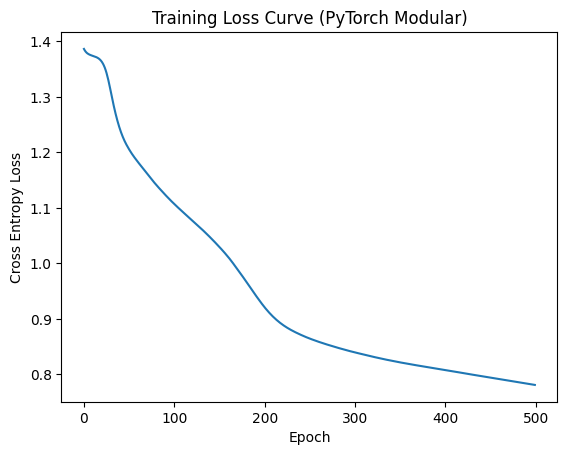

In [7]:
epochs    = 500
optimizer = optim.SGD(model.parameters(), lr=learning_rate)
losses    = []

model.train()
for epoch in range(epochs):
    # ---- 손실 계산 (Forward) ----
    loss = model.calculate_loss(X_train_t, Y_train_t)
    losses.append(loss.item())

    # ---- 역전파 + 가중치 업데이트 (Backward) ----
    optimizer.zero_grad()   # gradient 초기화
    loss.backward()         # 자동 미분: 모든 레이어 gradient 계산
    optimizer.step()        # W -= lr * dW

    if (epoch + 1) % 50 == 0:
        print(f'Epoch [{epoch+1}/{epochs}], Loss: {loss.item():.4f}')

# 학습 곡선 시각화
plt.plot(losses)
plt.title('Training Loss Curve (PyTorch Modular)')
plt.xlabel('Epoch')
plt.ylabel('Cross Entropy Loss')
plt.show()

### 5. 평가 및 시각화 (Evaluation & Visualization)
학습이 끝난 모델로 테스트 데이터를 추론하고, PCA로 2차원 축소하여 시각화합니다.

Overall Accuracy: 65.02%

PCA Explained Variance Ratio: PC1(0.44), PC2(0.18)


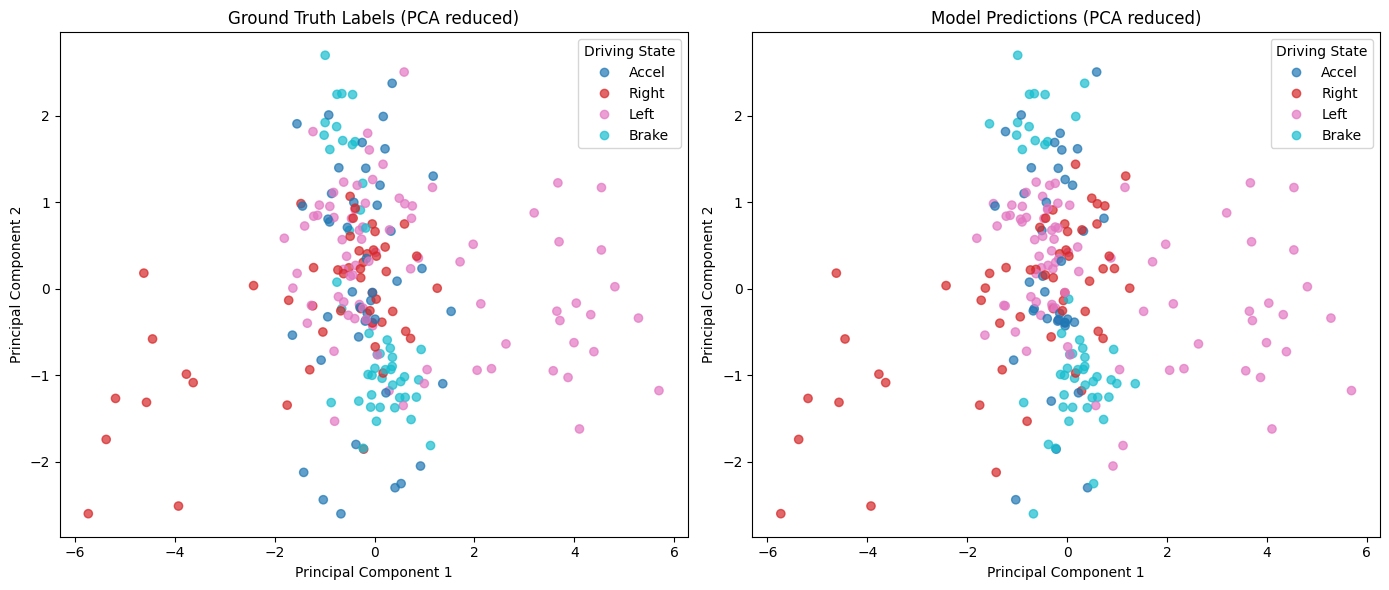

In [8]:
from sklearn.decomposition import PCA

# ---------------------------------------------------------
# 1. 모델 추론 (Test 데이터)
# ---------------------------------------------------------
model.eval()
with torch.no_grad():
    logits_test   = model(X_test_t)                      # forward only
    predictions_t = torch.argmax(logits_test, dim=1)

predictions = predictions_t.cpu().numpy()
accuracy    = np.mean(predictions == Y_test_np)
print(f'Overall Accuracy: {accuracy * 100:.2f}%\n')

# ---------------------------------------------------------
# 2. 결과 시각화 (PCA 2D 축소)
# ---------------------------------------------------------
pca        = PCA(n_components=2)
X_test_2d  = pca.fit_transform(X_test_np)

explained_variance = pca.explained_variance_ratio_
print(f"PCA Explained Variance Ratio: PC1({explained_variance[0]:.2f}), PC2({explained_variance[1]:.2f})")

plt.figure(figsize=(14, 6))
class_labels = ['Accel', 'Right', 'Left', 'Brake']

# 왼쪽: Ground Truth
plt.subplot(1, 2, 1)
scatter1 = plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1],
                       c=Y_test_np, cmap='tab10', alpha=0.7, edgecolors=None)
plt.title('Ground Truth Labels (PCA reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(handles=scatter1.legend_elements()[0], labels=class_labels, title='Driving State')

# 오른쪽: Model Predictions
plt.subplot(1, 2, 2)
scatter2 = plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1],
                       c=predictions, cmap='tab10', alpha=0.7, edgecolors=None)
plt.title('Model Predictions (PCA reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(handles=scatter2.legend_elements()[0], labels=class_labels, title='Driving State')

plt.tight_layout()
plt.show()